# SaTScan Cluster Analysis — EDA
Exploratory analysis of space-time cluster output from a retrospective SaTScan permutation scan.  
**Data:** LightGBM predicted risk scores, San Diego County, Jan 2022 – Dec 2024  
**Input file:** `data/satscan_cluster_outputs/lgbm_1pct_500m_12mo.clustermap_clusters.csv` — extracted from the SaTScan HTML output using `extract_satscan_all.py`

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# Plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.size":        11,
})
 
print("Libraries loaded.")

Libraries loaded.


## 1. Load Data

In [54]:
df = pd.read_csv("../../../data/satscan_cluster_outputs/lgbm_1pct_500m_12mo.clustermap_clusters.csv")
df.head()

,cluster_id,center_lat,center_lng,radius_m,radius_km,start_date,end_date,start_year,start_month,end_year,...,n_case_points,cases_centroid_lat,cases_centroid_lng,center_to_case_centroid_km,cases_bbox_lat_min,cases_bbox_lat_max,cases_bbox_lng_min,cases_bbox_lng_max,cases_bbox_lat_span_km,cases_bbox_lng_span_km
0,1,32.712906,-117.149373,90.164017,0.09016,2023/11/29,2024/2/27,2023,11,2024,...,1096,32.712995,-117.149538,0.0183,32.712134,32.713707,-117.150314,-117.148455,0.1749,0.1739
1,2,32.714485,-117.152421,27.620500,0.02762,2024/4/17,2024/8/13,2024,4,2024,...,519,32.714599,-117.152416,0.0126,32.714376,32.714732,-117.152663,-117.152134,0.0396,0.0495
2,3,32.740215,-117.158929,87.015582,0.08702,2022/2/23,2022/5/31,2022,2,2022,...,675,32.740134,-117.159109,0.0191,32.739457,32.740970,-117.159636,-117.158107,0.1682,0.1430
3,4,32.709286,-117.164844,77.782289,0.07778,2022/1/1,2022/3/15,2022,1,2022,...,312,32.709353,-117.164560,0.0275,32.708935,32.709936,-117.165537,-117.164078,0.1113,0.1365
4,5,32.721997,-117.167110,335.657225,0.33566,2024/8/14,2024/12/31,2024,8,2024,...,1084,32.721502,-117.165787,0.1355,32.718988,32.724945,-117.170678,-117.163559,0.6624,0.6660


## 2. Parse & Clean
Parse date columns, derive a midpoint date for each cluster, and ensure all numeric and boolean fields are correctly typed.

In [55]:
# Parse dates
df["start_date"] = pd.to_datetime(df["start_date"], format="%Y/%m/%d")
df["end_date"]   = pd.to_datetime(df["end_date"],   format="%Y/%m/%d")
 
# Midpoint date — useful for placing a cluster on a timeline
df["mid_date"] = df["start_date"] + (df["end_date"] - df["start_date"]) / 2
 
# Numeric casts (should already be numeric, but belt-and-suspenders)
num_cols = ["observed_cases", "expected_cases", "excess_cases",
            "obs_exp_ratio", "llr", "radius_km", "duration_days",
            "duration_weeks", "center_lat", "center_lng",
            "n_case_points", "center_to_case_centroid_km"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
 
# Boolean casts
df["is_high_rate"]    = df["is_high_rate"].astype(str).str.lower() == "true"
df["is_hierarchical"] = df["is_hierarchical"].astype(str).str.lower() == "true"
 
print(f"Loaded {len(df)} clusters.")
print(f"Date range: {df['start_date'].min().date()} → {df['end_date'].max().date()}")
df.head()

Loaded 500 clusters.
Date range: 2022-01-01 → 2024-12-31


,cluster_id,center_lat,center_lng,radius_m,radius_km,start_date,end_date,start_year,start_month,end_year,...,cases_centroid_lat,cases_centroid_lng,center_to_case_centroid_km,cases_bbox_lat_min,cases_bbox_lat_max,cases_bbox_lng_min,cases_bbox_lng_max,cases_bbox_lat_span_km,cases_bbox_lng_span_km,mid_date
0,1,32.712906,-117.149373,90.164017,0.09016,2023-11-29,2024-02-27,2023,11,2024,...,32.712995,-117.149538,0.0183,32.712134,32.713707,-117.150314,-117.148455,0.1749,0.1739,2024-01-13 00:00:00
1,2,32.714485,-117.152421,27.620500,0.02762,2024-04-17,2024-08-13,2024,4,2024,...,32.714599,-117.152416,0.0126,32.714376,32.714732,-117.152663,-117.152134,0.0396,0.0495,2024-06-15 00:00:00
2,3,32.740215,-117.158929,87.015582,0.08702,2022-02-23,2022-05-31,2022,2,2022,...,32.740134,-117.159109,0.0191,32.739457,32.740970,-117.159636,-117.158107,0.1682,0.1430,2022-04-12 12:00:00
3,4,32.709286,-117.164844,77.782289,0.07778,2022-01-01,2022-03-15,2022,1,2022,...,32.709353,-117.164560,0.0275,32.708935,32.709936,-117.165537,-117.164078,0.1113,0.1365,2022-02-06 12:00:00
4,5,32.721997,-117.167110,335.657225,0.33566,2024-08-14,2024-12-31,2024,8,2024,...,32.721502,-117.165787,0.1355,32.718988,32.724945,-117.170678,-117.163559,0.6624,0.6660,2024-10-22 12:00:00


## 3. Descriptive Summary
High-level summary statistics across all 500 detected clusters, including flag counts and temporal coverage.

In [56]:
summary_cols = ["observed_cases", "expected_cases", "excess_cases",
                "obs_exp_ratio", "llr", "radius_km",
                "duration_days", "n_case_points"]
 
print("=== Descriptive Statistics ===\n")
display(df[summary_cols].describe().round(2))
 
print("\n=== Cluster Flag Counts ===")
print(f"  High-rate clusters:    {df['is_high_rate'].sum()} / {len(df)}")
print(f"  Hierarchical clusters: {df['is_hierarchical'].sum()} / {len(df)}")
 
print("\n=== Temporal Coverage ===")
print(f"  Earliest start:  {df['start_date'].min().date()}")
print(f"  Latest end:      {df['end_date'].max().date()}")
print(f"  Median duration: {df['duration_days'].median():.0f} days  "
      f"({df['duration_weeks'].median():.1f} weeks)")

=== Descriptive Statistics ===



,observed_cases,expected_cases,excess_cases,obs_exp_ratio,llr,radius_km,duration_days,n_case_points
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,78.20,19.05,59.15,16.02,65.98,0.14,68.70,216.15
std,113.07,39.12,77.24,21.35,67.03,0.13,65.87,269.63
min,7.00,0.04,6.95,2.05,27.24,0.00,6.00,1.00
25%,22.00,1.32,20.49,4.51,34.00,0.04,20.00,45.00
50%,40.00,4.66,35.25,8.32,43.99,0.08,48.00,103.00
75%,82.00,18.38,60.33,18.43,70.25,0.21,90.00,266.00
max,909.00,359.78,642.01,221.32,813.36,0.50,356.00,1106.00



=== Cluster Flag Counts ===
  High-rate clusters:    500 / 500
  Hierarchical clusters: 500 / 500

=== Temporal Coverage ===
  Earliest start:  2022-01-01
  Latest end:      2024-12-31
  Median duration: 48 days  (6.9 weeks)


## 4. Distribution of Key Metrics
Histograms of the main cluster statistics. All distributions are right-skewed — the majority of clusters are small, short, and moderate in intensity, with a long tail of outliers.

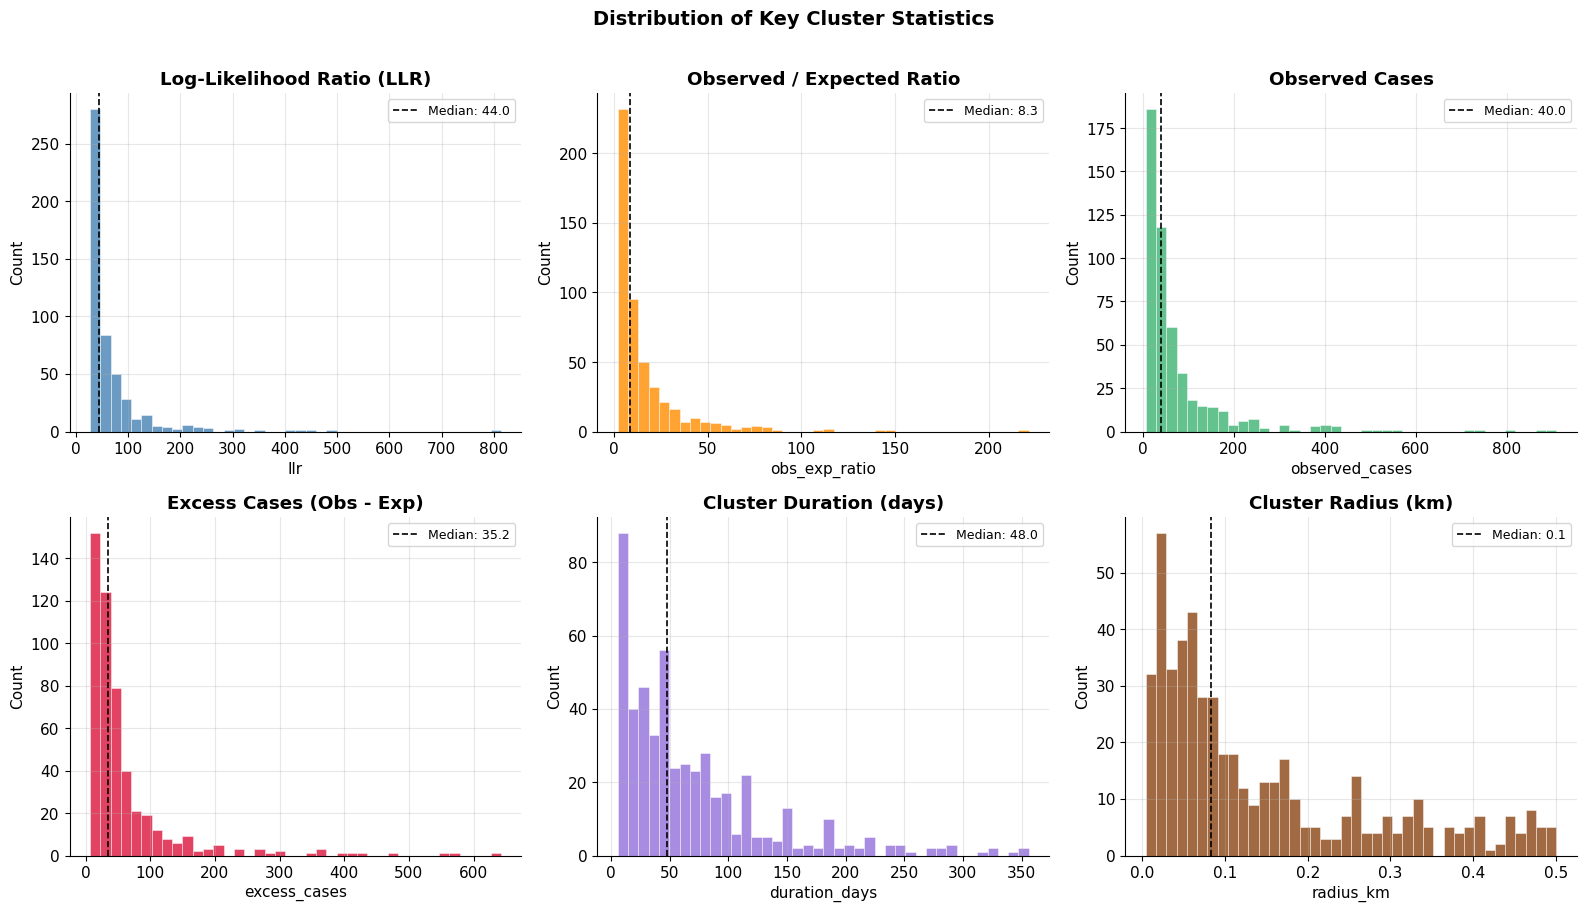

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribution of Key Cluster Statistics", fontsize=14, fontweight="bold", y=1.01)
 
panels = [
    ("llr",            "Log-Likelihood Ratio (LLR)",  "steelblue"),
    ("obs_exp_ratio",  "Observed / Expected Ratio",   "darkorange"),
    ("observed_cases", "Observed Cases",               "mediumseagreen"),
    ("excess_cases",   "Excess Cases (Obs - Exp)",    "crimson"),
    ("duration_days",  "Cluster Duration (days)",      "mediumpurple"),
    ("radius_km",      "Cluster Radius (km)",          "saddlebrown"),
]
 
for ax, (col, title, color) in zip(axes.flat, panels):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor="white", linewidth=0.4)
    ax.axvline(data.median(), color="black", linestyle="--", linewidth=1.2,
               label=f"Median: {data.median():.1f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
 
plt.tight_layout()
plt.show()

## 5. Temporal Patterns
### 5a. Cluster Starts by Month
Number of new clusters beginning each month across the study period. Reindexed to show every month continuously, including months with zero cluster starts.

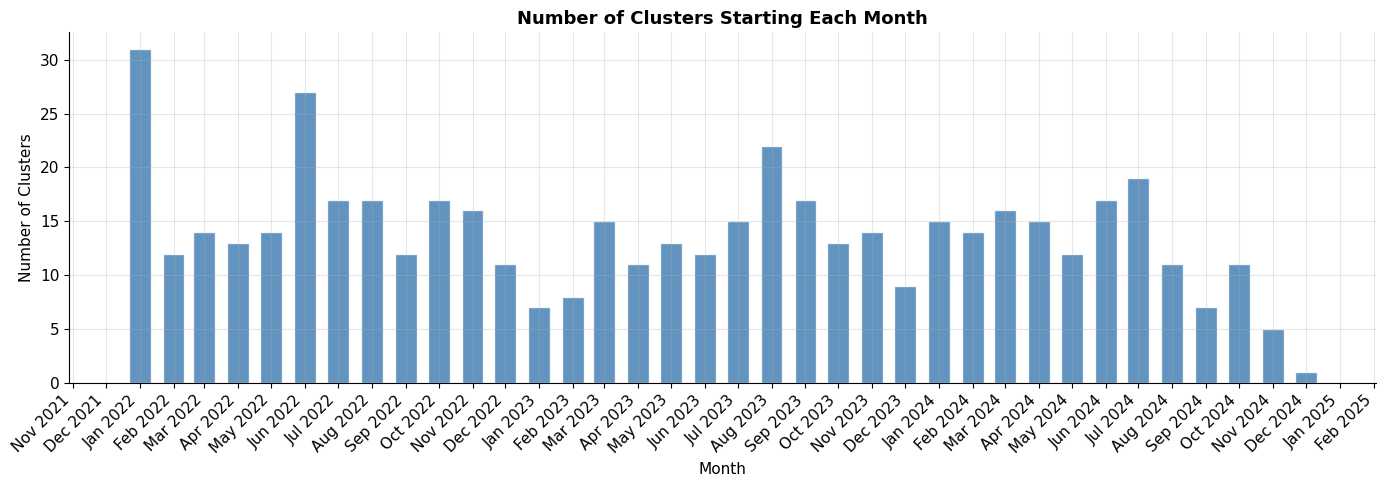

In [58]:
df["start_month_period"] = df["start_date"].dt.to_period("M")
monthly_starts = df.groupby("start_month_period").size().reset_index(name="n_clusters")

# Reindex to full continuous range so every month appears on the axis
full_range = pd.period_range(
    start=df["start_date"].min().to_period("M"),
    end=df["end_date"].max().to_period("M"),
    freq="M"
)
monthly_starts = (
    monthly_starts
    .set_index("start_month_period")
    .reindex(full_range, fill_value=0)
    .reset_index()
    .rename(columns={"index": "start_month_period"})
)
monthly_starts["date"] = monthly_starts["start_month_period"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_starts["date"], monthly_starts["n_clusters"],
       width=20, color="steelblue", alpha=0.85, edgecolor="white")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
ax.set_title("Number of Clusters Starting Each Month", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Clusters")
plt.tight_layout()
plt.show()

### 5b. Monthly Cluster Burden
Total observed cases and excess cases summed across clusters starting each month (top panel), and mean obs/exp ratio over time (bottom panel). The obs/exp ratio reflects signal intensity rather than volume.

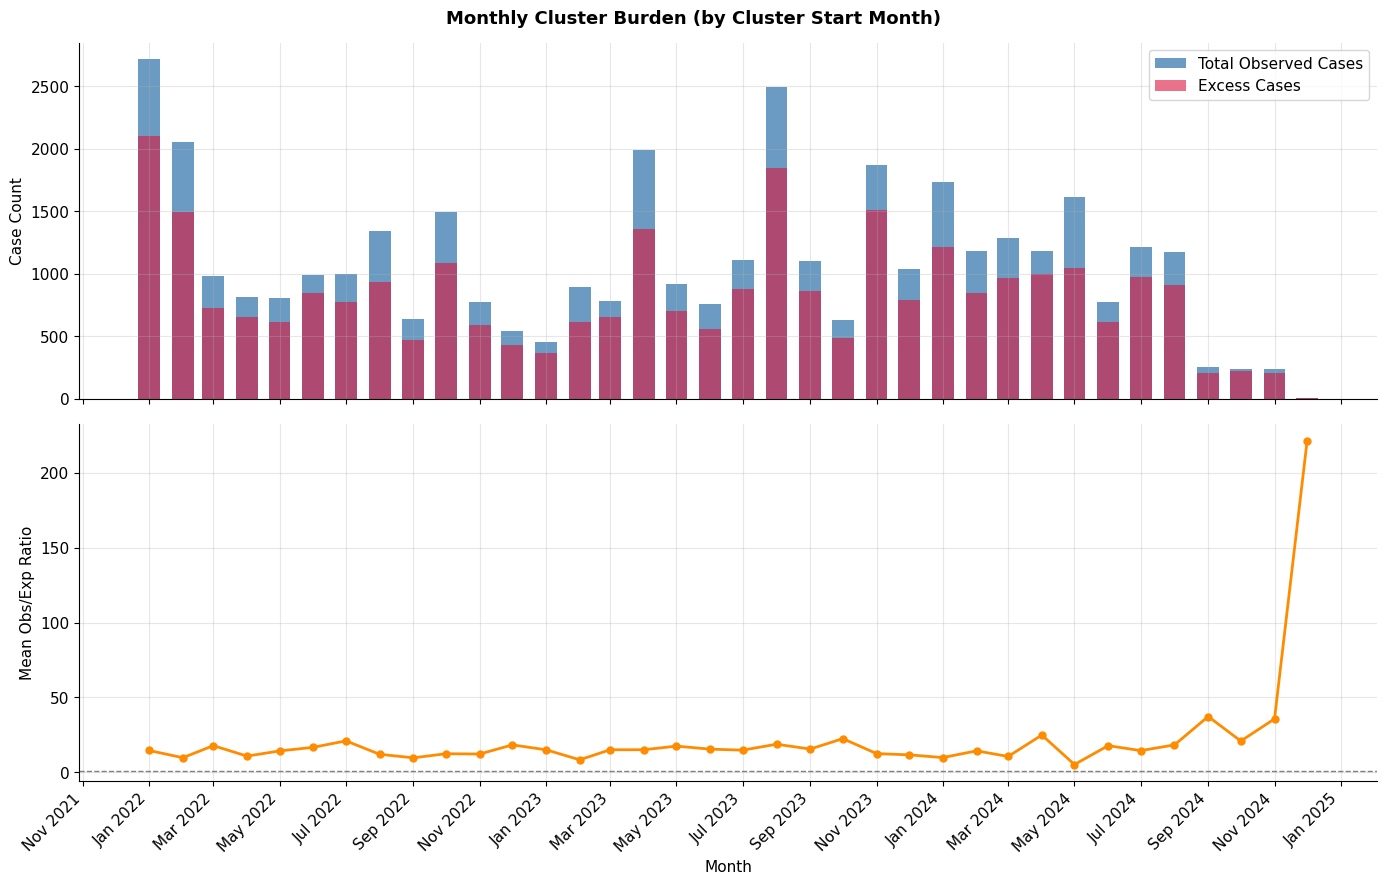

In [59]:
monthly_cases = df.groupby("start_month_period").agg(
    total_observed = ("observed_cases", "sum"),
    total_excess   = ("excess_cases",   "sum"),
    mean_obs_exp   = ("obs_exp_ratio",  "mean"),
).reset_index()
monthly_cases["date"] = monthly_cases["start_month_period"].dt.to_timestamp()
 
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle("Monthly Cluster Burden (by Cluster Start Month)",
             fontsize=13, fontweight="bold")
 
# Top: observed vs excess
axes[0].bar(monthly_cases["date"], monthly_cases["total_observed"],
            width=20, label="Total Observed Cases", color="steelblue", alpha=0.8)
axes[0].bar(monthly_cases["date"], monthly_cases["total_excess"],
            width=20, label="Excess Cases",         color="crimson",   alpha=0.6)
axes[0].set_ylabel("Case Count")
axes[0].legend()
 
# Bottom: mean obs/exp ratio
axes[1].plot(monthly_cases["date"], monthly_cases["mean_obs_exp"],
             color="darkorange", linewidth=2, marker="o", markersize=5)
axes[1].axhline(1, color="gray", linestyle="--", linewidth=1, label="Expected = Observed")
axes[1].set_ylabel("Mean Obs/Exp Ratio")
axes[1].set_xlabel("Month")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
 
plt.tight_layout()
plt.show()

### 5c. Top 60 Clusters — Duration Timeline (Gantt)
Each bar represents one cluster's active time window. Color encodes LLR — darker red = stronger statistical evidence. Sorted by start date within the top 60 by LLR.

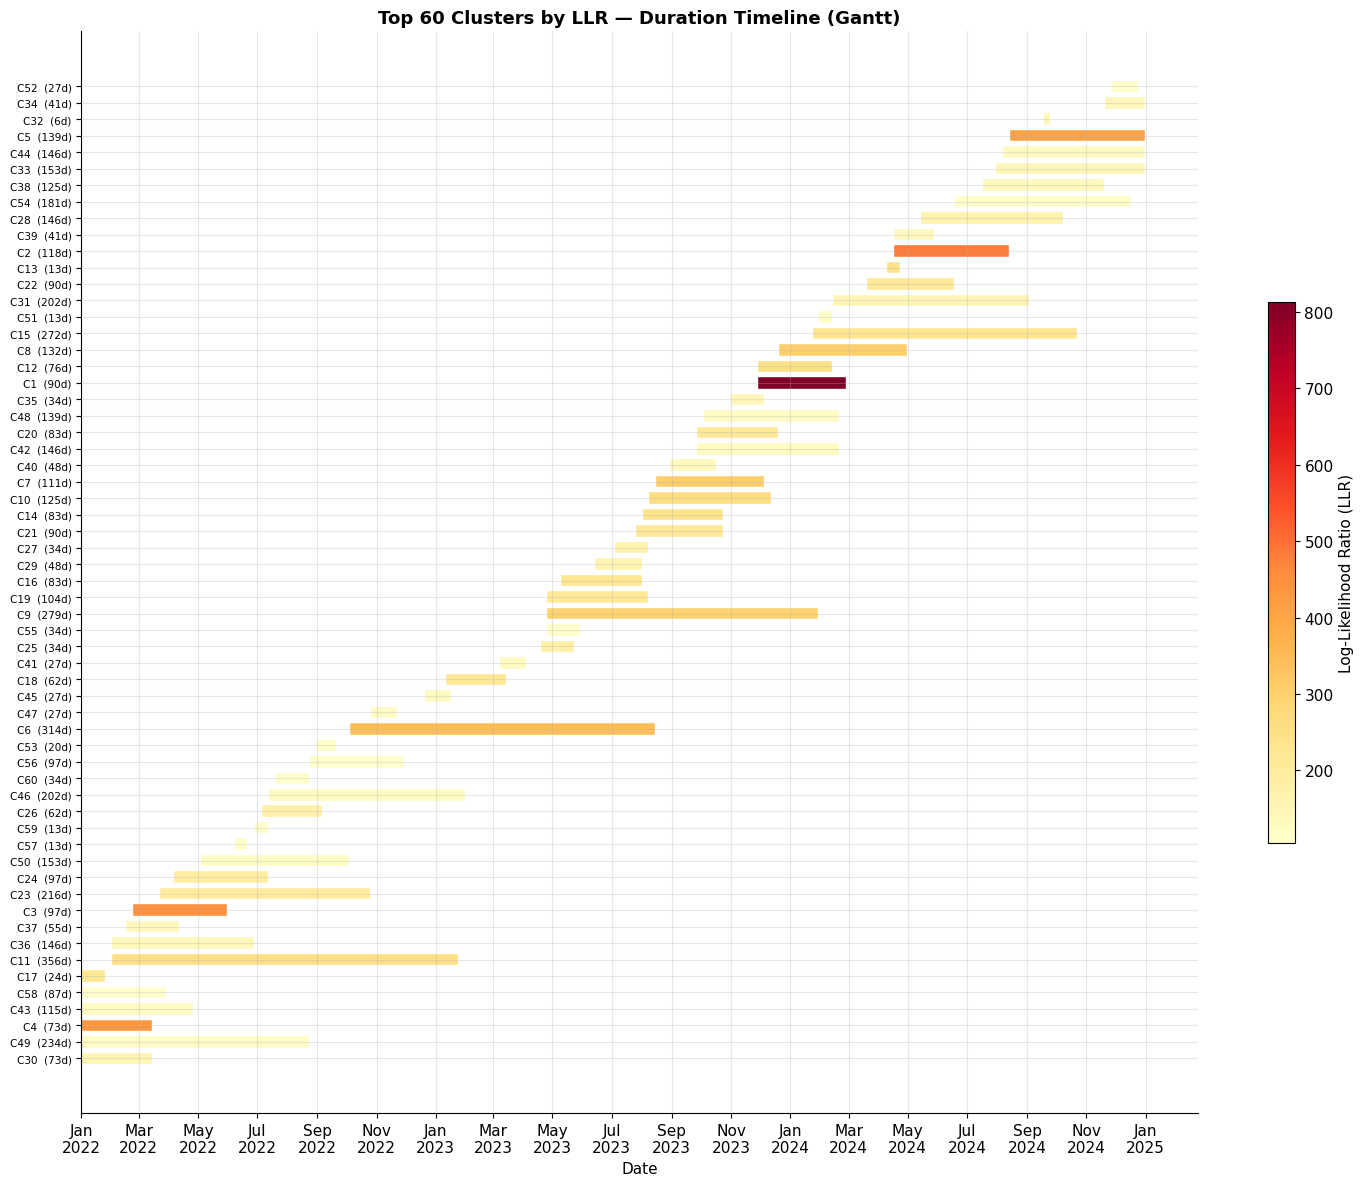

In [60]:
top_n = 60
top_df = df.nlargest(top_n, "llr").sort_values("start_date")
 
norm = mcolors.Normalize(vmin=top_df["llr"].min(), vmax=top_df["llr"].max())
cmap = cm.get_cmap("YlOrRd")
 
fig, ax = plt.subplots(figsize=(15, 12))
 
for i, (_, row) in enumerate(top_df.iterrows()):
    color = cmap(norm(row["llr"]))
    ax.barh(
        y=i,
        left=mdates.date2num(row["start_date"]),
        width=mdates.date2num(row["end_date"]) - mdates.date2num(row["start_date"]),
        color=color, edgecolor="white", linewidth=0.3, height=0.7
    )
 
ax.set_yticks(range(len(top_df)))
ax.set_yticklabels(
    [f"C{r['cluster_id']}  ({r['duration_days']}d)" for _, r in top_df.iterrows()],
    fontsize=7.5
)
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title(f"Top {top_n} Clusters by LLR — Duration Timeline (Gantt)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
 
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Log-Likelihood Ratio (LLR)", shrink=0.5)
plt.tight_layout()
plt.show()

### 5d. LLR vs Obs/Exp Ratio
Scatter plot separating statistical confidence (LLR, y-axis) from signal intensity (obs/exp ratio, x-axis). Bubble size encodes observed case count. Top 10 clusters by LLR are labeled.  
Note: high obs/exp does not always mean high LLR — small clusters can have dramatic rate elevation but limited statistical power due to low case counts.

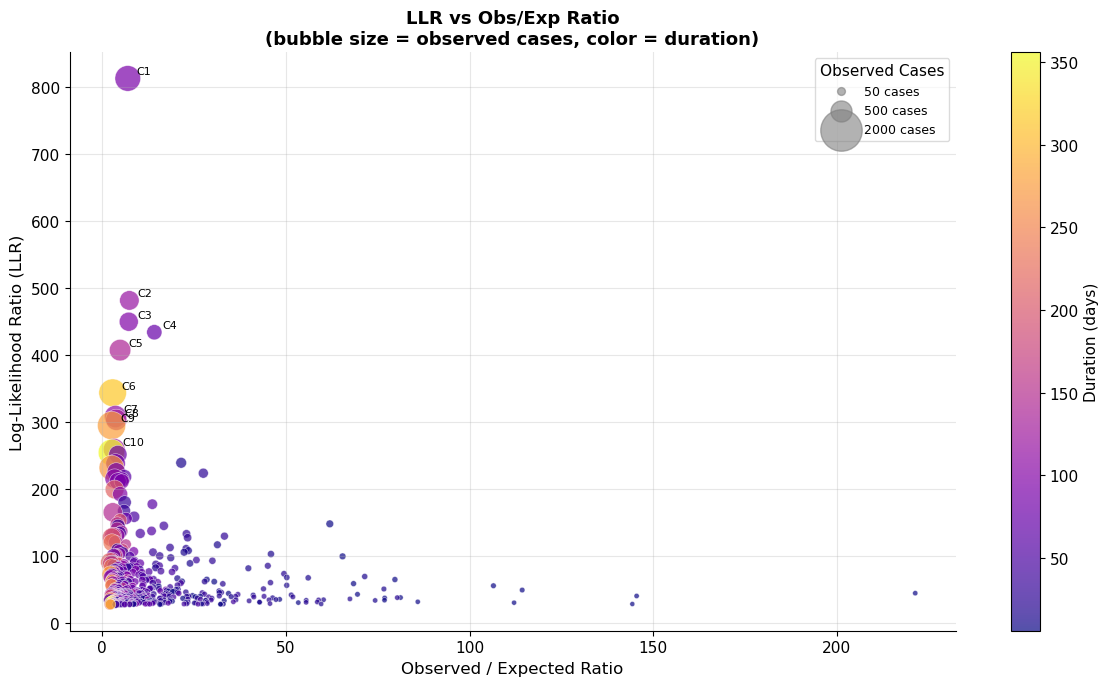

In [61]:
fig, ax = plt.subplots(figsize=(12, 7))
 
scatter = ax.scatter(
    df["obs_exp_ratio"],
    df["llr"],
    c=df["duration_days"],
    s=df["observed_cases"] / df["observed_cases"].max() * 400 + 10,
    cmap="plasma",
    alpha=0.7,
    edgecolors="white",
    linewidths=0.4
)
 
plt.colorbar(scatter, label="Duration (days)")
 
# Label top 10 by LLR
for _, row in df.nlargest(10, "llr").iterrows():
    ax.annotate(
        f"C{int(row['cluster_id'])}",
        (row["obs_exp_ratio"], row["llr"]),
        textcoords="offset points", xytext=(6, 3),
        fontsize=8, color="black"
    )
 
ax.set_xlabel("Observed / Expected Ratio", fontsize=12)
ax.set_ylabel("Log-Likelihood Ratio (LLR)", fontsize=12)
ax.set_title("LLR vs Obs/Exp Ratio\n(bubble size = observed cases, color = duration)",
             fontsize=13, fontweight="bold")
 
# Legend for bubble size
for cases, label in [(50, "50 cases"), (500, "500 cases"), (2000, "2000 cases")]:
    ax.scatter([], [], s=cases / df["observed_cases"].max() * 400 + 10,
               c="gray", alpha=0.6, label=label)
ax.legend(title="Observed Cases", framealpha=0.7, fontsize=9)
 
plt.tight_layout()
plt.show()